# Chothia to IMGT Position Mapping for IGHV genes - general mapping and GRAB motif mapping

This notebook creates a mapping from Chothia to IMGT numbering schemes for heavy chain V genes. 

We then use this mapping to extract GRAB (Germline-Reverted Antibody Binding) motifs in heavy chain V genes according to https://www.science.org/doi/10.1126/science.adc9498.

### Background: The Chothia-IMGT Mapping Challenge

The issue with mapping from IMGT to Chothia is that **there isn't a consistent mapping for all sites across all V genes**. This is documented in https://www.imgt.org/IMGTScientificChart/Numbering/CDR1-IMGTgaps.html, https://www.imgt.org/IMGTScientificChart/Numbering/CDR2-IMGTgaps.html.
Some sites are particularly problematic: Chothia 53, 54, 30, 31, 31.1 have variation within v family and between v families.

Grouping by specific v genes, all sites have a good consensus mapping across the sequences, which is the approach this notebook takes. 
It also adds a confidence score for every site and v gene combination to show how much agreement there is across that v gene - all confidence scores are over 97% (cell 4).
However, this means that the mapping is only for IGHV sections - meaning <= IMGT 106.

### Approach

1. Uses ANARCI outputs for the same sequences with both Chothia and IMGT schemes
2. Merges the outputs to align positions based on matching amino acids
3. Uses partis inference (extracted from pcp files) to get v gene inference for grouping, as it is more accurate than anarci for this.
4. Uses a **large dataset** (Rodriguez test dataset) to get consensus mappings per V gene
5. Calculates confidence scores reflecting mapping agreement across sequences

The notebook also tests which sites have poor disagreement across v genes within the same v family and between v families.

### Mapping Quality in GRAB motifs

For the **GRAB motifs in heavy chain V genes** (the focus of this analysis), all sites have a **confidence score of over 99%**, so the mappings should be reliable for downstream analysis.


### Output

The notebook creates a dataframe of heavy chain V gene GRAB motifs with IMGT mapping, saved to:
- `/fh/fast/matsen_e/shared/bcr-mut-sel/imgt_chothia_mapping/consensus_chothia_imgt_mapping_per_heavy_chain_vgene.csv`: Consensus mappings perheavy chain v gene (IGHV) with confidence scores
- `/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv`



In [1]:
from tqdm.auto import tqdm
tqdm.pandas()
import ast
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from dnsmex.local import localify
from netam.framework import load_pcp_df


figures_dir = localify("FIGURES_DIR")

In [2]:
# extract partis v genes from pcp files
partis_df = load_pcp_df('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/rodriguez-airr-seq-race-prod-NoWinCheck_igh_pcp_2024-11-12.csv.gz')
partis_df['sequence_id_for_merge'] = partis_df['sample_id'] + '|' + partis_df['family'].astype(str)
partis_df = partis_df[['sequence_id_for_merge', 'v_gene_heavy']].rename(columns={'v_gene_heavy': 'v_gene'})
partis_df = partis_df.drop_duplicates()


In [3]:
"""
CREATE CHOTHIA-IMGT POSITION MAPPINGS PER SEQUENCE
==============================================
Purpose: Build a mapping between Chothia and IMGT numbering schemes by aligning
         amino acid sequences from the same antibody sequences numbered in both schemes.

Input: Two CSV files with the same sequences numbered using Chothia and IMGT schemes
Output: Creates 'sequence_position_mappings_with_vgene.csv' used by subsequent cells

What it does:
1. Reads Chothia and IMGT numbered sequence files (uses the rodriguez test dataset, so will only include heavy chain v genes present there)
2. Matches amino acids between the two numbering schemes
3. Creates a mapping showing which Chothia position corresponds to which IMGT position
4. Saves mapping with V gene information for downstream analysis
5. Checks for inconsistencies across V genes
6. Visualizes the consensus mapping
"""


# Read both files
file1 = "/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_chothia.csv"
file2 = "/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/anarci/rodriguez-airr-seq-race-prod-NoWinCheck_igh_imgt.csv"

df1 = pd.read_csv(file1)
df2 = pd.read_csv(file2)

# Get the position columns (everything after the metadata columns)
metadata_cols = ['Id', 'domain_no', 'hmm_species', 'chain_type', 'e-value', 'score', 
                 'seqstart_index', 'seqend_index', 'identity_species', 'v_gene', 
                 'v_identity', 'j_gene', 'j_identity']

# Get position column names for each scheme
positions1 = [col for col in df1.columns if col not in metadata_cols]
positions2 = [col for col in df2.columns if col not in metadata_cols]

print(f"Numbering scheme 1 (Chothia) has {len(positions1)} positions")
print(f"Numbering scheme 2 (IMGT) has {len(positions2)} positions")

# Create mapping for each sequence
mappings = []

# Get common sequence IDs
common_ids = set(df1['Id']) & set(df2['Id'])
print(f"\nFound {len(common_ids)} common sequences")

# Process more sequences to get better statistics per V gene
for seq_id in list(common_ids):
    # Get the sequence from both files
    seq1_row = df1[df1['Id'] == seq_id].iloc[0]
    seq2_row = df2[df2['Id'] == seq_id].iloc[0]
    
    # Get v_gene for this sequence
    v_gene = seq1_row['v_gene']
    
    # Extract amino acids for each position
    seq1_aa = [seq1_row[pos] for pos in positions1]
    seq2_aa = [seq2_row[pos] for pos in positions2]
    
    # Create position mapping by matching amino acids
    pos_map = []
    j = 0  # pointer for seq2
    
    for i, aa1 in enumerate(seq1_aa):
        if aa1 != '-' and pd.notna(aa1):
            # Find matching amino acid in seq2
            while j < len(seq2_aa):
                aa2 = seq2_aa[j]
                if aa2 == aa1:
                    pos_map.append({
                        'sequence_id': seq_id,
                        'v_gene': v_gene,
                        'scheme1_position': positions1[i],
                        'scheme2_position': positions2[j],
                        'amino_acid': aa1,
                        'scheme1_index': i,
                        'scheme2_index': j
                    })
                    j += 1
                    break
                elif aa2 != '-' and pd.notna(aa2):
                    j += 1
                    break
                else:
                    j += 1
    
    mappings.extend(pos_map)

# Convert to DataFrame
mapping_df = pd.DataFrame(mappings)


##### replace anarci v gene with partis v gene #####
mapping_df['sequence_id_for_merge'] = mapping_df['sequence_id'].str.split('|').str[0] + '|' + mapping_df['sequence_id'].str.split('|').str[1]
mapping_df = pd.merge(mapping_df.drop(columns=['v_gene']), partis_df, on='sequence_id_for_merge', how='left')
mapping_df = mapping_df.drop(columns=['sequence_id_for_merge'])
##### end replace anarci v gene with partis v gene #####
                      

# Create a general position mapping (most common mapping across all sequences)
position_mapping = mapping_df.groupby(['scheme1_position', 'scheme2_position']).size().reset_index(name='count')
position_mapping = position_mapping.sort_values('count', ascending=False)

print("\nTop 20 position mappings between schemes:")
print(position_mapping.head(20))

# Check consistency across V genes
print("\n" + "="*80)
print("CHECKING CONSISTENCY ACROSS V GENES")
print("="*80)

# Create position mapping per V gene
position_mapping_by_vgene = (
    mapping_df.groupby(['v_gene', 'scheme1_position', 'scheme2_position'])
    .size()
    .reset_index(name='count')
)

# For each scheme1 position, check if it maps to the same scheme2 position across all V genes
inconsistencies = []

for chothia_pos in sorted(mapping_df['scheme1_position'].unique()):
    pos_mappings = position_mapping_by_vgene[
        position_mapping_by_vgene['scheme1_position'] == chothia_pos
    ][['v_gene', 'scheme2_position', 'count']].copy()
    
    most_common_per_vgene = (
        pos_mappings.sort_values('count', ascending=False)
        .groupby('v_gene').first().reset_index()
    )
    
    unique_imgt_positions = most_common_per_vgene['scheme2_position'].unique()
    
    if len(unique_imgt_positions) > 1:
        inconsistencies.append({
            'chothia_position': chothia_pos,
            'num_different_imgt_mappings': len(unique_imgt_positions),
            'imgt_positions': sorted(unique_imgt_positions),
            'details': most_common_per_vgene.to_dict('records')
        })

if inconsistencies:
    print(f"\nFound {len(inconsistencies)} Chothia positions with inconsistent IMGT mappings across V genes:\n")
    for incons in inconsistencies[:10]:
        print(f"Chothia position {incons['chothia_position']} maps to {incons['num_different_imgt_mappings']} different IMGT positions:")
        print(f"  IMGT positions: {incons['imgt_positions']}")
        print(f"  Details by V gene:")
        for detail in incons['details'][:5]:
            print(f"    {detail['v_gene']}: IMGT {detail['scheme2_position']} (count={detail['count']})")
        print()
else:
    print("\n✓ All Chothia positions map consistently to the same IMGT position across all V genes!")

# Save mapping for subsequent cells
mapping_df.to_csv('_output/sequence_position_mappings_with_vgene.csv', index=False)


Numbering scheme 1 (Chothia) has 150 positions
Numbering scheme 2 (IMGT) has 153 positions

Found 31738 common sequences

Top 20 position mappings between schemes:
    scheme1_position scheme2_position  count
366               93              105  31738
365               92              104  31738
364               91              103  31738
360               88              100  31738
363               90              102  31738
362                9                9  31738
361               89              101  31738
358               86               98  31738
359               87               99  31738
357               85               97  31738
356               84               96  31738
260               13               14  31738
355               83               95  31738
354             82.3               94  31738
353             82.2               93  31738
352             82.1               92  31738
351               82               91  31738
350               81      

In [4]:
"""
AGREEMENT/DISAGREEMENT WITHIN V GENES (IMGT ≤ 106 ONLY)
================================================================
Purpose: Analyze whether different sequences from the SAME V gene (e.g., different 
         instances of IGHV4-39*01) consistently map the same Chothia position to 
         the same IMGT position.

Input: Requires 'sequence_position_mappings_with_vgene.csv' from Cell 1
Output: Prints analysis to screen (no files saved)

What it does:
- For each V gene (e.g., IGHV4-39*01) and each Chothia position, checks if all
  sequences from that V gene agree on the IMGT mapping
- Identifies cases where ANARCI produces inconsistent numbering for the same V gene
- This is the most granular level of analysis (individual alleles)

Interpretation:
- High agreement = ANARCI is consistent in numbering this V gene
- Low agreement = ANARCI produces variable numbering, possibly due to:
  - Sequence quality issues
  - Alignment ambiguities in variable-length regions
  - True biological variation (indels) within the nominally same V gene
"""

# Load the mapping data
mapping_df = pd.read_csv('_output/sequence_position_mappings_with_vgene.csv')

# Filter to only include mappings where IMGT position is <= 106
mapping_df['scheme2_position_numeric'] = pd.to_numeric(
    mapping_df['scheme2_position'].astype(str).str.replace(r'[^0-9.]', '', regex=True), 
    errors='coerce'
)
mapping_df_filtered = mapping_df[mapping_df['scheme2_position_numeric'] <= 106].copy()

print("="*80)
print("ANALYSIS: AGREEMENT/DISAGREEMENT WITHIN V GENES (IMGT <= 106)")
print("="*80)
print(f"\nTotal mappings: {len(mapping_df_filtered)}")

v_genes = sorted(mapping_df_filtered['v_gene'].unique())
print(f"Found {len(v_genes)} V genes")

# For each V gene and Chothia position, check if there's consistent IMGT mapping
within_gene_analysis = []

for v_gene in v_genes:
    v_gene_data = mapping_df_filtered[mapping_df_filtered['v_gene'] == v_gene]
    
    # For each Chothia position in this V gene
    for chothia_pos in sorted(v_gene_data['scheme1_position'].unique()):
        pos_data = v_gene_data[v_gene_data['scheme1_position'] == chothia_pos]
        
        # Get all IMGT positions this Chothia position maps to
        imgt_mappings = pos_data['scheme2_position'].value_counts()
        unique_imgt = pos_data['scheme2_position'].unique()
        
        # Determine if there's agreement (all sequences agree on the mapping)
        has_agreement = len(unique_imgt) == 1
        
        within_gene_analysis.append({
            'v_gene': v_gene,
            'chothia_position': chothia_pos,
            'has_agreement': has_agreement,
            'num_sequences': len(pos_data),
            'num_unique_imgt_mappings': len(unique_imgt),
            'imgt_positions': sorted(unique_imgt.tolist()),
            'imgt_mapping_counts': imgt_mappings.to_dict()
        })

within_gene_df = pd.DataFrame(within_gene_analysis)

# Split into agreement and disagreement
gene_agreement = within_gene_df[within_gene_df['has_agreement']]
gene_disagreement = within_gene_df[~within_gene_df['has_agreement']]

print(f"\nSUMMARY - Within V Genes:")
print(f"  Total V gene + Chothia position combinations: {len(within_gene_df)}")
print(f"  With AGREEMENT (all sequences from gene agree): {len(gene_agreement)} ({len(gene_agreement)/len(within_gene_df)*100:.1f}%)")
print(f"  With DISAGREEMENT (sequences from gene disagree): {len(gene_disagreement)} ({len(gene_disagreement)/len(within_gene_df)*100:.1f}%)")

# Summary by V gene
gene_summary = within_gene_df.groupby('v_gene').agg({
    'has_agreement': ['sum', 'count'],
}).reset_index()
gene_summary.columns = ['v_gene', 'positions_with_agreement', 'total_positions']
gene_summary['positions_with_disagreement'] = gene_summary['total_positions'] - gene_summary['positions_with_agreement']
gene_summary['disagreement_percentage'] = (gene_summary['positions_with_disagreement'] / gene_summary['total_positions'] * 100)

# Show V genes with most disagreement
genes_with_issues = gene_summary[gene_summary['positions_with_disagreement'] > 0].sort_values('disagreement_percentage', ascending=False)

if len(genes_with_issues) > 0:
    print(f"\n\nV genes with disagreement (top 10 by percentage):")
    print(genes_with_issues.head(10).to_string(index=False))
else:
    print("\n✓ All V genes have perfect agreement!")

# Show specific examples of disagreement
if len(gene_disagreement) > 0:
    print(f"\n\nExamples of DISAGREEMENT within V genes (showing first 10):")
    for _, row in gene_disagreement.head(10).iterrows():
        print(f"\n  V gene: {row['v_gene']}, Chothia position: {row['chothia_position']}")
        print(f"    {row['num_sequences']} sequences analyzed")
        print(f"    Maps to {row['num_unique_imgt_mappings']} different IMGT positions:")
        
        # Show the distribution of mappings
        for imgt_pos, count in sorted(row['imgt_mapping_counts'].items()):
            percentage = count / row['num_sequences'] * 100
            print(f"      IMGT {imgt_pos}: {count} sequences ({percentage:.1f}%)")
    
    if len(gene_disagreement) > 10:
        print(f"\n  ... and {len(gene_disagreement) - 10} more positions with disagreement")

print("\n" + "="*80)
print("INTERPRETATION:")
print("="*80)
print("""
Disagreement within the same V gene typically indicates:
1. Sequence quality issues or ambiguous alignments
2. Variable-length regions (indels) where ANARCI makes different numbering choices
3. True biological variation (indels) within sequences assigned to the same V gene

For positions with disagreement, consider:
- Using the majority mapping
- Analyzing sequences individually rather than grouping by V gene
- Being cautious about using these positions for cross-sequence comparisons
""")

# Calculate confidence scores for all mappings
print("\n" + "="*80)
print("CONFIDENCE SCORE ANALYSIS")
print("="*80)

within_gene_df['confidence'] = within_gene_df.apply(
    lambda row: (max(row['imgt_mapping_counts'].values()) / row['num_sequences'] * 100)
    if row['imgt_mapping_counts'] else 100.0,
    axis=1
)

# Filter for sites with confidence < 100%
low_confidence = within_gene_df[within_gene_df['confidence'] < 100.0].copy()

print(f"\nTotal V gene + Chothia position combinations with confidence < 100%: {len(low_confidence)}")
print(f"Percentage of all combinations: {len(low_confidence)/len(within_gene_df)*100:.2f}%")

# Show distribution of confidence scores
print("\n" + "="*80)
print("CONFIDENCE SCORE DISTRIBUTION (for mappings with confidence < 100%):")
print("="*80)

if len(low_confidence) > 0:
    confidence_bins = [0, 50, 60, 70, 80, 90, 95, 99, 100]
    low_confidence['confidence_bin'] = pd.cut(low_confidence['confidence'], bins=confidence_bins, right=False)

    confidence_dist = low_confidence.groupby('confidence_bin', observed=True).size().reset_index(name='count')
    confidence_dist['percentage'] = (confidence_dist['count'] / len(low_confidence) * 100).round(2)

    print("\nConfidence range distribution:")
    for _, row in confidence_dist.iterrows():
        print(f"  {row['confidence_bin']}: {row['count']} sites ({row['percentage']:.1f}%)")

    # Show all sites with confidence < 100%
    print("\n" + "="*80)
    print("ALL SITES WITH CONFIDENCE < 100% (sorted by confidence):")
    print("="*80)

    low_confidence_sorted = low_confidence.sort_values('confidence')

    for _, row in low_confidence_sorted.iterrows():
        print(f"\n  {row['v_gene']}, Chothia {row['chothia_position']}: {row['confidence']:.1f}% confidence")
        print(f"    {row['num_sequences']} sequences analyzed")
        print(f"    Maps to {row['num_unique_imgt_mappings']} different IMGT positions:")

        # Show the distribution of mappings
        for imgt_pos, count in sorted(row['imgt_mapping_counts'].items(), key=lambda x: -x[1]):
            percentage = count / row['num_sequences'] * 100
            print(f"      IMGT {imgt_pos}: {count} sequences ({percentage:.1f}%)")

    # Summary statistics
    print("\n" + "="*80)
    print("CONFIDENCE STATISTICS:")
    print("="*80)
    print(f"  Minimum confidence: {low_confidence['confidence'].min():.2f}%")
    print(f"  Maximum confidence: {low_confidence['confidence'].max():.2f}%")
    print(f"  Mean confidence: {low_confidence['confidence'].mean():.2f}%")
    print(f"  Median confidence: {low_confidence['confidence'].median():.2f}%")

    # Sites by Chothia position
    print("\n" + "="*80)
    print("PROBLEMATIC CHOTHIA POSITIONS (with most occurrences of <100% confidence):")
    print("="*80)
    chothia_summary = low_confidence.groupby('chothia_position').agg({
        'v_gene': 'count',
        'confidence': 'mean'
    }).reset_index()
    chothia_summary.columns = ['chothia_position', 'num_v_genes_affected', 'avg_confidence']
    chothia_summary = chothia_summary.sort_values('num_v_genes_affected', ascending=False)

    print(chothia_summary.to_string(index=False))
else:
    print("\n✓ All V gene + Chothia position combinations have 100% confidence!")

ANALYSIS: AGREEMENT/DISAGREEMENT WITHIN V GENES (IMGT <= 106)

Total mappings: 3115448
Found 117 V genes

SUMMARY - Within V Genes:
  Total V gene + Chothia position combinations: 11489
  With AGREEMENT (all sequences from gene agree): 11483 (99.9%)
  With DISAGREEMENT (sequences from gene disagree): 6 (0.1%)


V genes with disagreement (top 10 by percentage):
     v_gene  positions_with_agreement  total_positions  positions_with_disagreement  disagreement_percentage
IGHV3-11*04                        97               99                            2                 2.020202
IGHV3-23*04                        97               99                            2                 2.020202
IGHV4-61*01                        97               99                            2                 2.020202


Examples of DISAGREEMENT within V genes (showing first 10):

  V gene: IGHV3-11*04, Chothia position: 53.0
    83 sequences analyzed
    Maps to 2 different IMGT positions:
      IMGT 58.0: 2 sequenc

In [5]:
"""
AGREEMENT/DISAGREEMENT BETWEEWN AND WITHIN VFAMILIES ANALYSIS (IMGT ≤ 106 ONLY)
==========================================================
Purpose: Analyze where Chothia and IMGT numbering schemes agree/disagree for positions
         up to and including IMGT 106 (covering Framework and CDR regions before CDR3).

Input: Requires 'sequence_position_mappings_with_vgene.csv' from Cell 1
Output: Prints two analyses to screen (no files saved)

What it does:
ANALYSIS 1 - WITHIN V FAMILIES:
  - For each V family (IGHV1, IGHV2, etc.), checks if all genes in that family agree
    on how a Chothia position maps to IMGT
  - Example: Do all IGHV4 genes (IGHV4-39*01, IGHV4-34*01, etc.) map Chothia 52 to the same IMGT position?
  
ANALYSIS 2 - BETWEEN V FAMILIES:
  - Checks if different V families map the same Chothia position to the same IMGT position
  - Example: Does Chothia 52 map to IMGT 54 in all families, or does it vary by family?
  
This helps determine:
- Which Chothia positions safely group homologous sites across all V families
- Which positions are family-specific and need separate handling
"""


# Load the mapping data
mapping_df = pd.read_csv('_output/sequence_position_mappings_with_vgene.csv')

# Filter to only include mappings where IMGT position is <= 106
mapping_df['scheme2_position_numeric'] = pd.to_numeric(
    mapping_df['scheme2_position'].astype(str).str.replace(r'[^0-9.]', '', regex=True), 
    errors='coerce'
)
mapping_df_filtered = mapping_df[mapping_df['scheme2_position_numeric'] <= 106].copy()

# Extract V family from V gene name (e.g., IGHV4-39*01 -> IGHV4)
mapping_df_filtered['v_family'] = mapping_df_filtered['v_gene'].str.extract(r'(IGHV\d+)', expand=False)

print("="*80)
print("CHOTHIA-IMGT MAPPING ANALYSIS (IMGT <= 106)")
print("="*80)
print(f"\nTotal mappings before filtering: {len(mapping_df)}")
print(f"Total mappings after filtering (IMGT <= 106): {len(mapping_df_filtered)}")

v_families = sorted(mapping_df_filtered['v_family'].dropna().unique())
v_genes = sorted(mapping_df_filtered['v_gene'].unique())
print(f"\nFound {len(v_families)} V families: {', '.join(v_families)}")
print(f"Found {len(v_genes)} V genes")

print("\n" + "="*80)
print("ANALYSIS 1: AGREEMENT/DISAGREEMENT WITHIN V FAMILIES")
print("="*80)
print("(Checking if genes within the same family agree on Chothia → IMGT mapping)")

# For each V family and Chothia position, check if all genes in that family agree
within_family_analysis = []

for v_family in v_families:
    family_data = mapping_df_filtered[mapping_df_filtered['v_family'] == v_family]
    genes_in_family = family_data['v_gene'].unique()
    
    # For each Chothia position in this family
    for chothia_pos in sorted(family_data['scheme1_position'].unique()):
        pos_data = family_data[family_data['scheme1_position'] == chothia_pos]
        
        # Find the consensus mapping per gene
        gene_mappings = {}
        for gene in pos_data['v_gene'].unique():
            gene_data = pos_data[pos_data['v_gene'] == gene]
            most_common = gene_data['scheme2_position'].value_counts().index[0]
            gene_mappings[gene] = most_common
        
        # Check if all genes agree
        unique_imgt_positions = set(gene_mappings.values())
        has_agreement = len(unique_imgt_positions) == 1
        
        within_family_analysis.append({
            'v_family': v_family,
            'chothia_position': chothia_pos,
            'has_agreement': has_agreement,
            'num_genes': len(gene_mappings),
            'num_sequences': len(pos_data),
            'num_unique_imgt_mappings': len(unique_imgt_positions),
            'imgt_positions': sorted(list(unique_imgt_positions)),
            'gene_mappings': gene_mappings
        })

within_family_df = pd.DataFrame(within_family_analysis)

# Split into agreement and disagreement
within_agreement = within_family_df[within_family_df['has_agreement']]
within_disagreement = within_family_df[~within_family_df['has_agreement']]

print(f"\nSUMMARY - Within V Family:")
print(f"  Total V family + Chothia position combinations: {len(within_family_df)}")
print(f"  With AGREEMENT (all genes in family agree): {len(within_agreement)} ({len(within_agreement)/len(within_family_df)*100:.1f}%)")
print(f"  With DISAGREEMENT (genes in family disagree): {len(within_disagreement)} ({len(within_disagreement)/len(within_family_df)*100:.1f}%)")

# Summary by V family
within_family_summary = within_family_df.groupby('v_family').agg({
    'has_agreement': ['sum', 'count'],
}).reset_index()
within_family_summary.columns = ['v_family', 'positions_with_agreement', 'total_positions']
within_family_summary['positions_with_disagreement'] = within_family_summary['total_positions'] - within_family_summary['positions_with_agreement']
within_family_summary['disagreement_percentage'] = (within_family_summary['positions_with_disagreement'] / within_family_summary['total_positions'] * 100)

print(f"\nBreakdown by V family:")
print(within_family_summary.to_string(index=False))

if len(within_disagreement) > 0:
    print(f"\n\nPositions with DISAGREEMENT within families (showing first 10):")
    for _, row in within_disagreement.head(10).iterrows():
        print(f"\n  {row['v_family']}, Chothia {row['chothia_position']}:")
        print(f"    {row['num_genes']} genes map to {row['num_unique_imgt_mappings']} different IMGT positions")
        # Group genes by IMGT mapping
        imgt_to_genes = {}
        for gene, imgt_pos in row['gene_mappings'].items():
            if imgt_pos not in imgt_to_genes:
                imgt_to_genes[imgt_pos] = []
            imgt_to_genes[imgt_pos].append(gene)
        for imgt_pos in sorted(imgt_to_genes.keys()):
            print(f"      IMGT {imgt_pos}: {', '.join(imgt_to_genes[imgt_pos])}")
    
    if len(within_disagreement) > 10:
        print(f"\n  ... and {len(within_disagreement) - 10} more positions with disagreement")

print("\n" + "="*80)
print("ANALYSIS 2: AGREEMENT/DISAGREEMENT BETWEEN V FAMILIES")
print("="*80)
print("(Checking if different V families map the same Chothia position to the same IMGT position)")

# For each Chothia position, check if all V families agree on the IMGT mapping
between_family_analysis = []

for chothia_pos in sorted(mapping_df_filtered['scheme1_position'].unique()):
    pos_data = mapping_df_filtered[mapping_df_filtered['scheme1_position'] == chothia_pos]
    
    # For each V family, find the consensus IMGT mapping
    family_mappings = {}
    for v_family in pos_data['v_family'].dropna().unique():
        family_data = pos_data[pos_data['v_family'] == v_family]
        most_common = family_data['scheme2_position'].value_counts().index[0]
        family_mappings[v_family] = most_common
    
    # Check if all families agree
    unique_imgt_positions = set(family_mappings.values())
    has_agreement = len(unique_imgt_positions) == 1
    
    between_family_analysis.append({
        'chothia_position': chothia_pos,
        'has_agreement': has_agreement,
        'num_families': len(family_mappings),
        'num_sequences': len(pos_data),
        'num_unique_imgt_mappings': len(unique_imgt_positions),
        'imgt_positions': sorted(list(unique_imgt_positions)),
        'family_mappings': family_mappings
    })

between_family_df = pd.DataFrame(between_family_analysis)

# Split into agreement and disagreement
between_agreement = between_family_df[between_family_df['has_agreement']]
between_disagreement = between_family_df[~between_family_df['has_agreement']]

print(f"\nSUMMARY - Between V Families:")
print(f"  Total Chothia positions: {len(between_family_df)}")
print(f"  With AGREEMENT (all families agree): {len(between_agreement)} ({len(between_agreement)/len(between_family_df)*100:.1f}%)")
print(f"  With DISAGREEMENT (families disagree): {len(between_disagreement)} ({len(between_disagreement)/len(between_family_df)*100:.1f}%)")

if len(between_disagreement) > 0:
    print(f"\n\nChothia positions with DISAGREEMENT between families (showing first 15):")
    for _, row in between_disagreement.head(15).iterrows():
        print(f"\n  Chothia {row['chothia_position']}:")
        print(f"    {row['num_families']} families map to {row['num_unique_imgt_mappings']} different IMGT positions")
        # Group families by IMGT mapping
        imgt_to_families = {}
        for family, imgt_pos in row['family_mappings'].items():
            if imgt_pos not in imgt_to_families:
                imgt_to_families[imgt_pos] = []
            imgt_to_families[imgt_pos].append(family)
        for imgt_pos in sorted(imgt_to_families.keys()):
            print(f"      IMGT {imgt_pos}: {', '.join(imgt_to_families[imgt_pos])}")
    
    if len(between_disagreement) > 15:
        print(f"\n  ... and {len(between_disagreement) - 15} more positions with disagreement")

CHOTHIA-IMGT MAPPING ANALYSIS (IMGT <= 106)

Total mappings before filtering: 3879173
Total mappings after filtering (IMGT <= 106): 3115448

Found 7 V families: IGHV1, IGHV2, IGHV3, IGHV4, IGHV5, IGHV6, IGHV7
Found 117 V genes

ANALYSIS 1: AGREEMENT/DISAGREEMENT WITHIN V FAMILIES
(Checking if genes within the same family agree on Chothia → IMGT mapping)

SUMMARY - Within V Family:
  Total V family + Chothia position combinations: 695
  With AGREEMENT (all genes in family agree): 690 (99.3%)
  With DISAGREEMENT (genes in family disagree): 5 (0.7%)

Breakdown by V family:
v_family  positions_with_agreement  total_positions  positions_with_disagreement  disagreement_percentage
   IGHV1                        98               98                            0                 0.000000
   IGHV2                        99               99                            0                 0.000000
   IGHV3                       100              102                            2                 1.960784

In [6]:
"""
CREATE CONSENSUS CHOTHIA-IMGT MAPPING PER V GENE (IMGT ≤ 106)
======================================================================
Purpose: Create a comprehensive lookup table showing the consensus mapping from 
         Chothia to IMGT positions for each V gene.

Input: Requires 'sequence_position_mappings_with_vgene.csv' from Cell 1
Output: DataFrame 'consensus_mapping_per_vgene' with columns:
        - v_gene: The V gene (e.g., IGHV4-39*01)
        - v_family: The V family (e.g., IGHV4)
        - chothia_position: Chothia position (e.g., 31, 31.1, 52A)
        - imgt_position: Consensus IMGT position
        - num_sequences: How many sequences support this mapping
        - confidence: Percentage of sequences agreeing (100% = perfect consensus)

Note about Chothia notation:
- Positions like "31.1" represent insertions (equivalent to "31A" in traditional notation)
- Decimal format: 31.1 = 31A, 31.2 = 31B, 52.1 = 52A, etc.
- This is ANARCI's way of representing insertion codes numerically
"""

import pandas as pd
import numpy as np

# Load the mapping data
mapping_df = pd.read_csv('_output/sequence_position_mappings_with_vgene.csv')

# Filter to IMGT <= 106
mapping_df['scheme2_position_numeric'] = pd.to_numeric(
    mapping_df['scheme2_position'].astype(str).str.replace(r'[^0-9.]', '', regex=True), 
    errors='coerce'
)
mapping_df_filtered = mapping_df[mapping_df['scheme2_position_numeric'] <= 106].copy()

# Extract V family
mapping_df_filtered['v_family'] = mapping_df_filtered['v_gene'].str.extract(r'(IGHV\d+)', expand=False)

print("="*80)
print("CREATING CONSENSUS CHOTHIA-IMGT MAPPING PER V GENE")
print("="*80)

# For each V gene and Chothia position, find the consensus IMGT mapping
consensus_mappings = []

for v_gene in sorted(mapping_df_filtered['v_gene'].unique()):
    v_gene_data = mapping_df_filtered[mapping_df_filtered['v_gene'] == v_gene]
    v_family = v_gene_data['v_family'].iloc[0]
    
    for chothia_pos in sorted(v_gene_data['scheme1_position'].unique()):
        pos_data = v_gene_data[v_gene_data['scheme1_position'] == chothia_pos]
        
        # Get the most common IMGT mapping
        imgt_counts = pos_data['scheme2_position'].value_counts()
        consensus_imgt = imgt_counts.index[0]
        consensus_count = imgt_counts.iloc[0]
        total_sequences = len(pos_data)
        confidence = (consensus_count / total_sequences) * 100
        
        consensus_mappings.append({
            'v_gene': v_gene,
            'v_family': v_family,
            'chothia_position': chothia_pos,
            'imgt_position': consensus_imgt,
            'num_sequences': total_sequences,
            'consensus_count': consensus_count,
            'confidence': confidence,
            'is_ambiguous': len(imgt_counts) > 1
        })

# Create the consensus mapping DataFrame
consensus_mapping_per_vgene = pd.DataFrame(consensus_mappings)

print(f"\nCreated consensus mapping with {len(consensus_mapping_per_vgene)} rows")
print(f"Covering {consensus_mapping_per_vgene['v_gene'].nunique()} V genes")
print(f"Covering {consensus_mapping_per_vgene['chothia_position'].nunique()} unique Chothia positions")

# Check mapping quality
perfect_mappings = consensus_mapping_per_vgene[consensus_mapping_per_vgene['confidence'] == 100]
ambiguous_mappings = consensus_mapping_per_vgene[consensus_mapping_per_vgene['is_ambiguous']]

print(f"\nMapping quality:")
print(f"  Perfect consensus (100% agreement): {len(perfect_mappings)} ({len(perfect_mappings)/len(consensus_mapping_per_vgene)*100:.1f}%)")
print(f"  Ambiguous (multiple mappings exist): {len(ambiguous_mappings)} ({len(ambiguous_mappings)/len(consensus_mapping_per_vgene)*100:.1f}%)")

# Show the DataFrame
print("\n" + "="*80)
print("SAMPLE OF CONSENSUS MAPPING (first 20 rows):")
print("="*80)
print(consensus_mapping_per_vgene[['v_gene', 'chothia_position', 'imgt_position', 'confidence']].head(20).to_string(index=False))

# Show some examples of ambiguous mappings
if len(ambiguous_mappings) > 0:
    print("\n" + "="*80)
    print("EXAMPLES OF AMBIGUOUS MAPPINGS (low confidence):")
    print("="*80)
    low_confidence = ambiguous_mappings.sort_values('confidence').head(10)
    print(low_confidence[['v_gene', 'chothia_position', 'imgt_position', 'confidence', 'consensus_count', 'num_sequences']].to_string(index=False))

# Show example of Chothia insertion positions
# Convert to string first to use string methods
consensus_mapping_per_vgene['chothia_position_str'] = consensus_mapping_per_vgene['chothia_position'].astype(str)
insertion_positions = consensus_mapping_per_vgene[consensus_mapping_per_vgene['chothia_position_str'].str.contains(r'\.', regex=True, na=False)]

if len(insertion_positions) > 0:
    print("\n" + "="*80)
    print("EXAMPLES OF CHOTHIA INSERTION POSITIONS (decimal notation):")
    print("="*80)
    print("Note: 31.1 = 31A, 31.2 = 31B, 52.1 = 52A, etc.")
    print()
    print(insertion_positions[['v_gene', 'chothia_position', 'imgt_position']].head(15).to_string(index=False))

# Drop the temporary string column
consensus_mapping_per_vgene = consensus_mapping_per_vgene.drop('chothia_position_str', axis=1)

print("\n" + "="*80)
print("DATAFRAME CREATED: 'consensus_mapping_per_vgene'")
print("="*80)
print("""
You can now use this DataFrame to:
1. Look up the IMGT position for any V gene + Chothia position combination
2. Filter by v_family to get family-specific mappings
3. Filter by confidence to get only high-confidence mappings
4. Use as a lookup table for converting between numbering schemes

Example usage:
  # Get mapping for a specific V gene and Chothia position
  mapping = consensus_mapping_per_vgene[
      (consensus_mapping_per_vgene['v_gene'] == 'IGHV4-39*01') & 
      (consensus_mapping_per_vgene['chothia_position'] == '52')
  ]
  
  # Get all mappings for a V family
  ighv4_mappings = consensus_mapping_per_vgene[
      consensus_mapping_per_vgene['v_family'] == 'IGHV4'
  ]
  
  # Get only high-confidence mappings
  confident_mappings = consensus_mapping_per_vgene[
      consensus_mapping_per_vgene['confidence'] >= 95
  ]
""")

# save to file
consensus_mapping_per_vgene.to_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/imgt_chothia_mapping/consensus_chothia_imgt_mapping_per_heavy_chain_vgene.csv', index=False)

CREATING CONSENSUS CHOTHIA-IMGT MAPPING PER V GENE

Created consensus mapping with 11489 rows
Covering 117 V genes
Covering 104 unique Chothia positions

Mapping quality:
  Perfect consensus (100% agreement): 11483 (99.9%)
  Ambiguous (multiple mappings exist): 6 (0.1%)

SAMPLE OF CONSENSUS MAPPING (first 20 rows):
     v_gene  chothia_position  imgt_position  confidence
IGHV1-18*01               1.0            1.0       100.0
IGHV1-18*01               2.0            2.0       100.0
IGHV1-18*01               3.0            3.0       100.0
IGHV1-18*01               4.0            4.0       100.0
IGHV1-18*01               5.0            5.0       100.0
IGHV1-18*01               6.0            6.0       100.0
IGHV1-18*01               7.0            7.0       100.0
IGHV1-18*01               8.0            8.0       100.0
IGHV1-18*01               9.0            9.0       100.0
IGHV1-18*01              10.0           11.0       100.0
IGHV1-18*01              11.0           12.0       100.0

## GRAB motifs - Chothia to IMGT positions

In [3]:
# read human GRAB motifs from paper supplementary table
grab_motif_df = pd.read_excel('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/Table_S11_adc9498_Suppl. Excel_seq9_v3.xlsx', sheet_name='Table_S11_tab_C', header=2).drop(columns=['Unnamed: 0'])
# read consensus mapping of chothia to imgt per v gene
consensus_mapping_per_vgene.read_csv = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/imgt_chothia_mapping/consensus_chothia_imgt_mapping_per_heavy_chain_vgene.csv')

# Convert string representation of list to actual list
grab_motif_df['Antibody_GRAB_motif'] = grab_motif_df['Antibody_GRAB_motif'].apply(ast.literal_eval)

# Keep the original full list in a new column
grab_motif_df['Antibody_GRAB_motif_full'] = grab_motif_df['Antibody_GRAB_motif']

grab_motif_df['Human V gene'] = grab_motif_df['Human V gene'].ffill()

# Explode the column - each list element becomes a new row
df_exploded = grab_motif_df.explode('Antibody_GRAB_motif')

# Reset index if needed
df_exploded = df_exploded.reset_index(drop=True)

df_exploded['chotia_site'] = df_exploded.Antibody_GRAB_motif.str[1:]
df_exploded['amino_acid'] = df_exploded.Antibody_GRAB_motif.str[0]


def convert_position_with_insertion(pos_str):
    """Convert position with insertion code to numeric format
    e.g., '100A' -> '100.1', '100B' -> '100.2'
    """
    alphabet = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    pos_str = str(pos_str).strip()
    
    # Check if last character is alphabetic
    if pos_str and pos_str[-1].isalpha():
        base = pos_str[:-1]
        letter = pos_str[-1].upper()
        insertion_num = alphabet.index(letter) + 1
        return f"{base}.{insertion_num}"
    else:
        return pos_str

df_exploded['chotia_site_numeric'] = df_exploded['chotia_site'].apply(convert_position_with_insertion)
df_exploded['chotia_site_numeric'] = df_exploded['chotia_site_numeric'].astype(float)
df_exploded.rename(columns={'Human V gene':'v_gene'}, inplace=True)
df_exploded['v_gene'] = df_exploded.v_gene.str.upper()

# only IGHV
df_exploded = df_exploded[df_exploded.v_gene.str.startswith('IGHV')]


# for cases where no single allele added, add one to match consensus mapping. 
df_exploded['v_gene'] = df_exploded['v_gene'].apply(lambda x: x if '*' in x else f"{x}*01")
# When multiple - choose an allele that exists in consensus mapping.
df_exploded['v_gene'] = df_exploded['v_gene'].str.replace('IGHV3-11*03, *05, *06', 'IGHV3-11*05')


### get final mapping (only for v gene area, so until IMGT <= 106)
grab_motifs_mapped = pd.merge(df_exploded, consensus_mapping_per_vgene.rename(columns={'chothia_position':'chotia_site_numeric'}), on=['chotia_site_numeric', 'v_gene'], how='left')

# add germline annotation
germline_df = pd.read_csv('germline/germline_codons.csv')
grab_motifs_mapped = pd.merge(grab_motifs_mapped, germline_df.rename(columns={'site':'imgt_position', 'amino_acid':'germline_amino_acid'})[['imgt_position', 'v_gene', 'germline_amino_acid']], on=['v_gene', 'imgt_position'], how='left')

grab_motifs_mapped


/tmp/ipykernel_478724/2306029263.py:4: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  consensus_mapping_per_vgene.read_csv = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/imgt_chothia_mapping/consensus_chothia_imgt_mapping_per_heavy_chain_vgene.csv')


,v_gene,Antigen_Residue,Antibody_GRAB_motif,Examples,Antibody_GRAB_motif_full,chotia_site,amino_acid,chotia_site_numeric,v_family,imgt_position,num_sequences,consensus_count,confidence,is_ambiguous,germline_amino_acid
0,IGHV3-21*01,"D, E",S52,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",52,S,52.0,IGHV3,57.0,968.0,968.0,100.0,False,S
1,IGHV3-21*01,"D, E",S52A,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",52A,S,52.1,IGHV3,58.0,968.0,968.0,100.0,False,S
2,IGHV3-21*01,"D, E",S53,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",53,S,53.0,IGHV3,59.0,968.0,968.0,100.0,False,S
3,IGHV3-21*01,"D, E",S55,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",55,S,55.0,IGHV3,63.0,968.0,968.0,100.0,False,S
4,IGHV3-21*01,"D, E",Y56,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",56,Y,56.0,IGHV3,64.0,968.0,968.0,100.0,False,Y
5,IGHV3-11*05,"D, E",S52,hypothetical,"[S52, S52A, S53, S55, Y56]",52,S,52.0,IGHV3,57.0,19.0,19.0,100.0,False,S
6,IGHV3-11*05,"D, E",S52A,hypothetical,"[S52, S52A, S53, S55, Y56]",52A,S,52.1,IGHV3,58.0,19.0,19.0,100.0,False,S
7,IGHV3-11*05,"D, E",S53,hypothetical,"[S52, S52A, S53, S55, Y56]",53,S,53.0,IGHV3,59.0,19.0,19.0,100.0,False,S
8,IGHV3-11*05,"D, E",S55,hypothetical,"[S52, S52A, S53, S55, Y56]",55,S,55.0,IGHV3,63.0,19.0,19.0,100.0,False,S
9,IGHV3-11*05,"D, E",Y56,hypothetical,"[S52, S52A, S53, S55, Y56]",56,Y,56.0,IGHV3,64.0,19.0,19.0,100.0,False,Y


In [8]:
grab_motifs_mapped[['v_gene', 'Antigen_Residue', 'Antibody_GRAB_motif', 'Examples',
       'Antibody_GRAB_motif_full', 'chotia_site', 'amino_acid',
       'chotia_site_numeric', 'v_family', 'imgt_position', 'confidence', 'germline_amino_acid']].to_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/grab_motifs/grab_motifs_human_ighv_chothia_to_imgt_mapping.csv', index=False)

## Examine sites with disagreements

In [2]:
consensus_mapping_per_vgene = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/imgt_chothia_mapping/consensus_chothia_imgt_mapping_per_heavy_chain_vgene.csv')


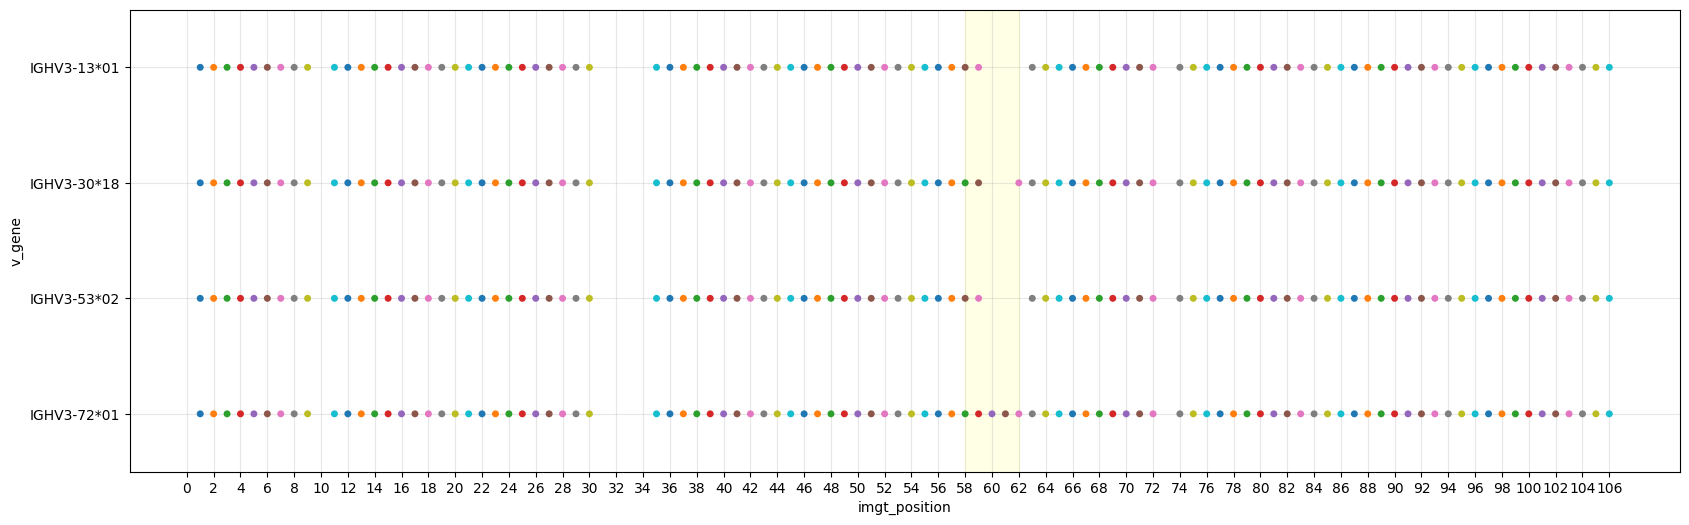

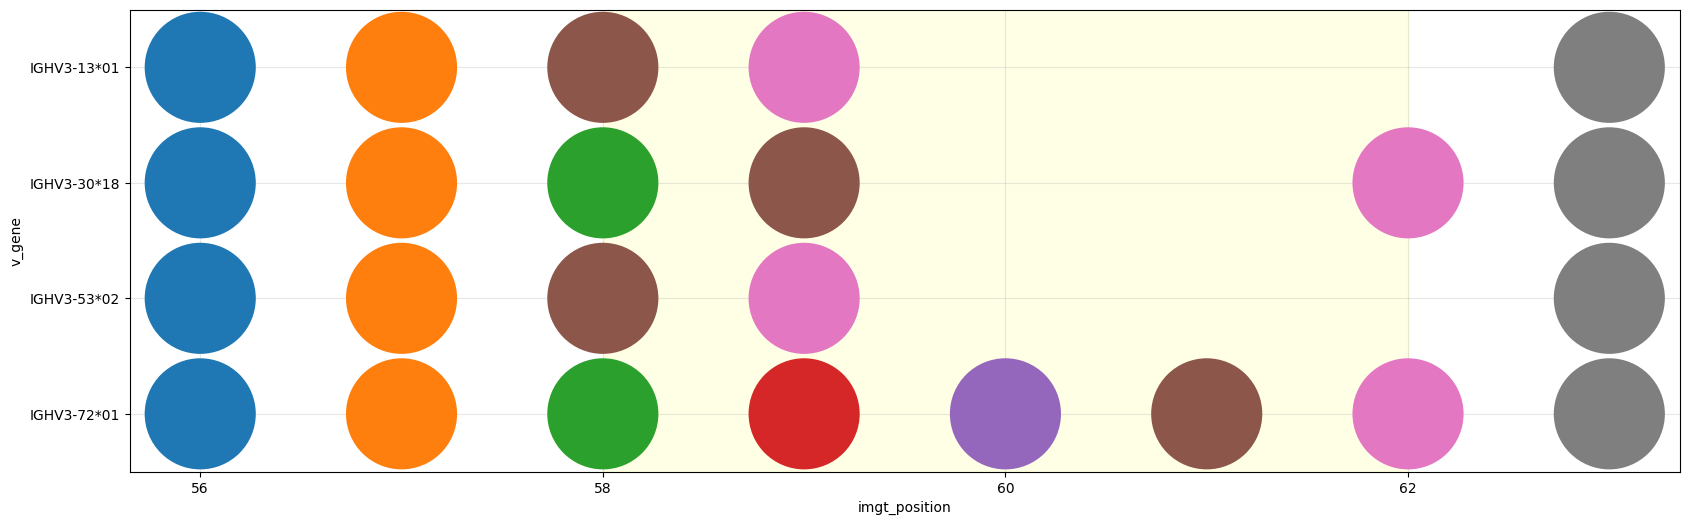

In [24]:
# IGHV3 CDR2

plot_data = consensus_mapping_per_vgene[consensus_mapping_per_vgene.v_gene.isin(['IGHV3-53*02', 'IGHV3-30*18', 'IGHV3-13*01', 'IGHV3-72*01'])]

fig, ax = plt.subplots(figsize=(20, 6))
sns.stripplot(data=plot_data, x='imgt_position', y='v_gene', jitter=False, hue='chothia_position', ax=ax, palette='tab10')
# remove legend
ax.set_xticks(range(0, 107, 2))
ax.grid(alpha=0.3)
ax.axvspan(58, 62, alpha=0.1, color='yellow', zorder=0)
ax.legend().remove()


plot_data = plot_data[plot_data.imgt_position.isin(range(56, 64))]
fig, ax = plt.subplots(figsize=(20, 6))
sns.stripplot(data=plot_data, x='imgt_position', y='v_gene', jitter=False, hue='chothia_position', ax=ax, palette='tab10', size=80)
# remove legend
ax.set_xticks(range(0, 107, 2))
ax.grid(alpha=0.3)
ax.axvspan(58, 62, alpha=0.1, color='yellow', zorder=0)
ax.legend().remove()

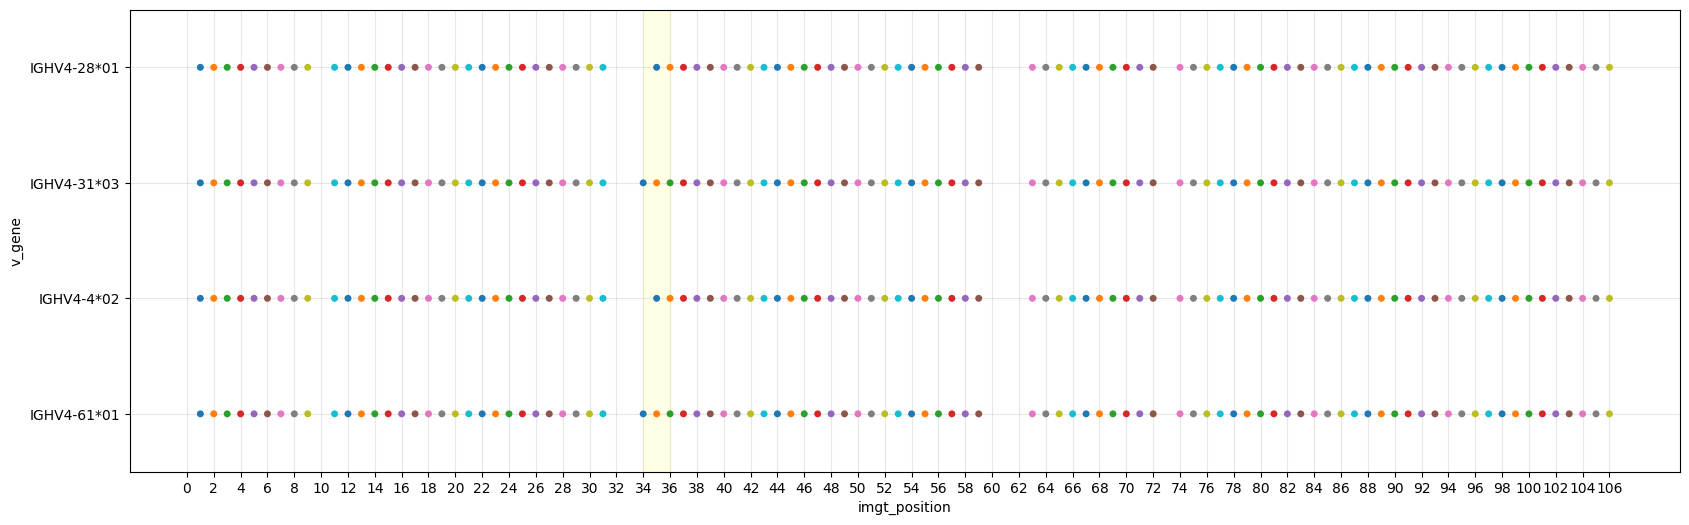

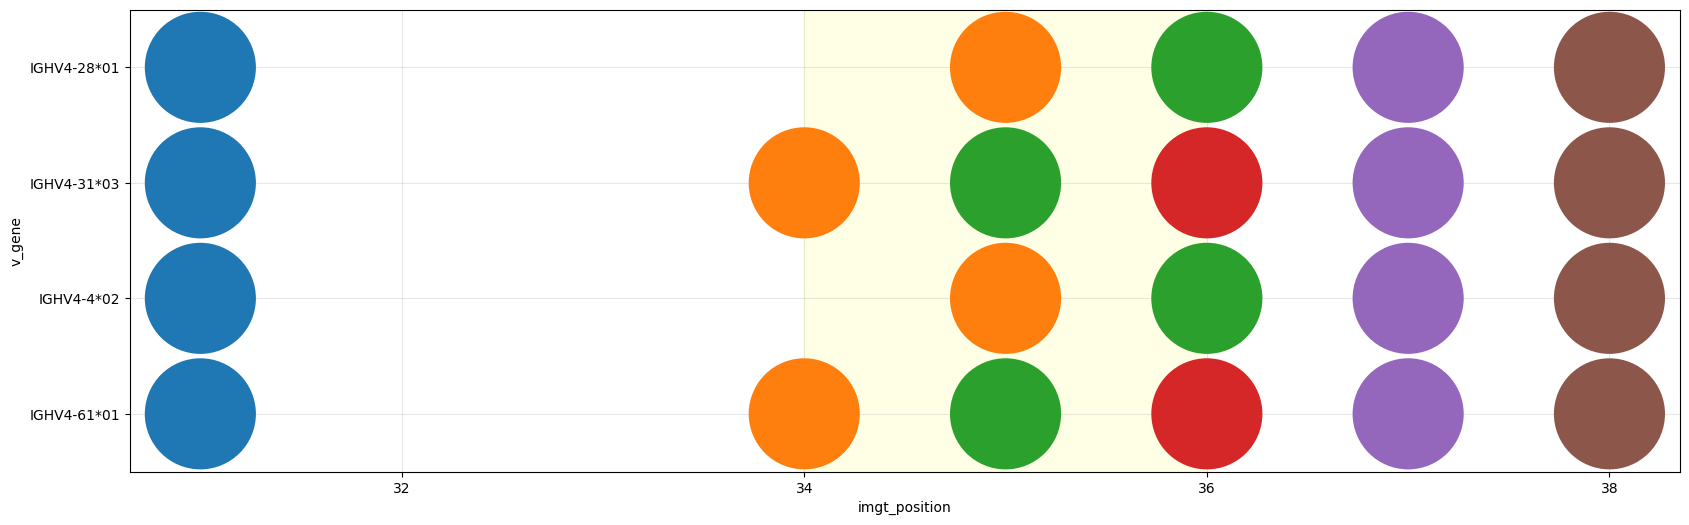

In [27]:
# IGHV4 CDR1

plot_data = consensus_mapping_per_vgene[consensus_mapping_per_vgene.v_gene.isin(['IGHV4-31*03', 'IGHV4-61*01', 'IGHV4-28*01', 'IGHV4-4*02'])]

fig, ax = plt.subplots(figsize=(20, 6))
sns.stripplot(data=plot_data, x='imgt_position', y='v_gene', jitter=False, hue='chothia_position', ax=ax, palette='tab10')
# remove legend
ax.set_xticks(range(0, 107, 2))
ax.grid(alpha=0.3)
ax.axvspan(34, 36, alpha=0.1, color='yellow', zorder=0)
ax.legend().remove()


plot_data = plot_data[plot_data.imgt_position.isin(range(31, 39))]
fig, ax = plt.subplots(figsize=(20, 6))
sns.stripplot(data=plot_data, x='imgt_position', y='v_gene', jitter=False, hue='chothia_position', ax=ax, palette='tab10', size=80)
# remove legend
ax.set_xticks(range(0, 107, 2))
ax.grid(alpha=0.3)
ax.axvspan(34, 36, alpha=0.1, color='yellow', zorder=0)
ax.legend().remove()

In [8]:
grab_motifs_mapped#[grab_motifs_mapped.imgt_position.isin(range(58, 63))]

,v_gene,Antigen_Residue,Antibody_GRAB_motif,Examples,Antibody_GRAB_motif_full,chotia_site,amino_acid,chotia_site_numeric,v_family,imgt_position,num_sequences,consensus_count,confidence,is_ambiguous,germline_amino_acid
0,IGHV3-21*01,"D, E",S52,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",52,S,52.0,IGHV3,57.0,968.0,968.0,100.0,False,S
1,IGHV3-21*01,"D, E",S52A,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",52A,S,52.1,IGHV3,58.0,968.0,968.0,100.0,False,S
2,IGHV3-21*01,"D, E",S53,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",53,S,53.0,IGHV3,59.0,968.0,968.0,100.0,False,S
3,IGHV3-21*01,"D, E",S55,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",55,S,55.0,IGHV3,63.0,968.0,968.0,100.0,False,S
4,IGHV3-21*01,"D, E",Y56,4 of 8 unique PDB Ab-Ag structures involving I...,"[S52, S52A, S53, S55, Y56]",56,Y,56.0,IGHV3,64.0,968.0,968.0,100.0,False,Y
5,IGHV3-11*05,"D, E",S52,hypothetical,"[S52, S52A, S53, S55, Y56]",52,S,52.0,IGHV3,57.0,19.0,19.0,100.0,False,S
6,IGHV3-11*05,"D, E",S52A,hypothetical,"[S52, S52A, S53, S55, Y56]",52A,S,52.1,IGHV3,58.0,19.0,19.0,100.0,False,S
7,IGHV3-11*05,"D, E",S53,hypothetical,"[S52, S52A, S53, S55, Y56]",53,S,53.0,IGHV3,59.0,19.0,19.0,100.0,False,S
8,IGHV3-11*05,"D, E",S55,hypothetical,"[S52, S52A, S53, S55, Y56]",55,S,55.0,IGHV3,63.0,19.0,19.0,100.0,False,S
9,IGHV3-11*05,"D, E",Y56,hypothetical,"[S52, S52A, S53, S55, Y56]",56,Y,56.0,IGHV3,64.0,19.0,19.0,100.0,False,Y


In [ ]:
concens